# Full Pipeline: pyccl → Database → Emulator

This notebook demonstrates the complete tissage-cosmique workflow using all three
packages together:

- **macon** — CRUD database operations for `CosmologyParams`
- **tisserande** — `@track` provenance recording of computations
- **tissage-cosmique** — pyccl wrappers, emulators, and DB-backed training

### Pipeline steps
1. Initialize the database and configure tisserande tracking
2. Store cosmological parameter sets in the DB (macon CRUD)
3. Run tracked computations — provenance stored automatically
4. Inspect the stored provenance graph
5. Reconstruct training data from the DB (no re-running pyccl)
6. Train a GP emulator on the queried data
7. Validate against pyccl truth

In [1]:
import nest_asyncio
nest_asyncio.apply()

import numpy as np
import matplotlib.pyplot as plt

## 1. Initialize the database and configure tracking

We use a file-backed SQLite database. Since macon, tisserande, and tissage-cosmique
all share the same `Base`, a single `init_db` + `create_all` creates all tables:
`cosmology_params` (tissage-cosmique) and `execution/node/edge` (tisserande).

In [2]:
import asyncio
import tisserande.db  # registers tisserande tables with shared Base
from tissage_cosmique.db.base import Base, init_db, get_session, close_db

DB_URL = "sqlite+aiosqlite:///pipeline_demo.db"

asyncio.run(close_db())
init_db(DB_URL)

async def _setup():
    async with get_session() as session:
        conn = await session.connection()
        await conn.run_sync(Base.metadata.drop_all)
        await conn.run_sync(Base.metadata.create_all)

asyncio.run(_setup())

table_names = sorted(Base.metadata.tables.keys())
print(f"{len(table_names)} tables created:")
for t in table_names:
    print(f"  {t}")

27 tables created:
  array
  array_node
  class
  config_dict_node
  config_dict_type
  config_file_node
  config_file_type
  cosmology_params
  data_file_node
  data_file_type
  edge
  execution
  member_function
  member_function_node
  node
  object_node
  parameter
  parameter_node
  python_function
  python_function_node
  shell_function
  shell_function_node
  test_list_pair
  test_named
  test_ref
  test_table
  test_uuid


<sys>:0: SAWarning: Can't sort tables for DROP; an unresolvable foreign key dependency exists between tables: execution, node; and backend does not support ALTER.  To restore at least a partial sort, apply use_alter=True to ForeignKey and ForeignKeyConstraint objects involved in the cycle to mark these as known cycles that will be ignored.


In [3]:
from tisserande.tracking.backends import LocalSyncBackend
from tisserande.tracking.decorator import configure

configure(backend=LocalSyncBackend())
print("Tracking configured with LocalSyncBackend")

Tracking configured with LocalSyncBackend


## 2. Store cosmological parameter sets in the DB

Using macon's CRUD layer via `tissage_cosmique.local_sync.cosmology_params`.

In [4]:
from tissage_cosmique.local_sync import cosmology_params

FIXED_PARAMS = dict(Omega_b=0.0486, n_s=0.9667, Omega_k=0.0, w0=-1.0, wa=0.0)

rng = np.random.default_rng(42)
n_train = 30

stored_params = []
for i in range(n_train):
    row = cosmology_params.create_row(
        name=f"train_{i:03d}",
        Omega_c=rng.uniform(0.22, 0.32),
        h=rng.uniform(0.62, 0.75),
        sigma8=rng.uniform(0.77, 0.87),
        **FIXED_PARAMS,
    )
    stored_params.append(row)

print(f"Stored {len(stored_params)} CosmologyParams records in the DB")
print(f"\nFirst 3:")
for p in stored_params[:3]:
    print(f"  {p.name}: Omega_c={p.Omega_c:.4f}, h={p.h:.4f}, sigma8={p.sigma8:.4f} (id={p.id_})")

2026-09-17 14:02:05 [debug    ] Creating row                   fields=['name', 'Omega_c', 'h', 'sigma8', 'Omega_b', 'n_s', 'Omega_k', 'w0', 'wa'] table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Row created                    row_id=None table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Creating row                   fields=['name', 'Omega_c', 'h', 'sigma8', 'Omega_b', 'n_s', 'Omega_k', 'w0', 'wa'] table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Row created                    row_id=None table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Creating row                   fields=['name', 'Omega_c', 'h', 'sigma8', 'Omega_b', 'n_s', 'Omega_k', 'w0', 'wa'] table=CosmologyParamsTable


...

2026-09-17 14:02:05 [debug    ] Creating row                   fields=['name', 'Omega_c', 'h', 'sigma8', 'Omega_b', 'n_s', 'Omega_k', 'w0', 'wa'] table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Row created                    row_id=None table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Creating row                   fields=['name', 'Omega_c', 'h', 'sigma8', 'Omega_b', 'n_s', 'Omega_k', 'w0', 'wa'] table=CosmologyParamsTable


2026-09-17 14:02:05 [debug    ] Row created                    row_id=None table=CosmologyParamsTable


Stored 30 CosmologyParams records in the DB

First 3:
  train_000: Omega_c=0.2974, h=0.6771, sigma8=0.8559 (id=01a0b12d-34e6-7aa2-bb00-9578da6d09cb)
  train_001: Omega_c=0.2897, h=0.6322, sigma8=0.8676 (id=01a0b12d-34e8-7a10-b6e0-3636755ff3f8)
  train_002: Omega_c=0.2961, h=0.7222, sigma8=0.7828 (id=01a0b12d-34ea-7591-9976-201c3bce07c0)


## 3. Run tracked computations

The `comoving_angular_distance` function is decorated with `@track`, so every call
automatically records an execution with input/output nodes and edges in the DB.

In [5]:
from tissage_cosmique.computations.distances import comoving_angular_distance

PARAM_NAMES = ["Omega_c", "h", "sigma8"]
a_grid = np.linspace(0.2, 0.8, 30)

print(f"Running {n_train} tracked computations...")
for p in stored_params:
    params_dict = p.model_dump(exclude={"id_"})
    comoving_angular_distance(params_dict, a_grid)

print("Done — provenance stored automatically by @track")

Running 30 tracked computations...
2026-09-17 14:02:05 [debug    ] Creating row                   fields=['status', 'start_time'] table=ExecutionTable


2026-09-17 14:02:05 [debug    ] Row created                    row_id=None table=ExecutionTable


2026-09-17 14:02:05 [debug    ] Creating node row              fields=['type_', 'execution_id', 'arg_name']


2026-09-17 14:02:05 [debug    ] Updating row                   fields=['function_node_id'] row_id=UUID('01a0b12d-351d-79a1-97ba-4e7412bf4d1b') table=ExecutionTable


2026-09-17 14:02:05 [info     ] Row updated successfully       row_id=UUID('01a0b12d-351d-79a1-97ba-4e7412bf4d1b') table=ExecutionTable


...

2026-09-17 14:02:06 [debug    ] Creating row                   fields=['from_id', 'to_id', 'execution_id'] table=EdgeTable


2026-09-17 14:02:06 [debug    ] Row created                    row_id=None table=EdgeTable


2026-09-17 14:02:06 [debug    ] Updating row                   fields=['status', 'duration_seconds', 'end_time'] row_id=UUID('01a0b12d-3c50-79c1-b84a-8f48a50a9bad') table=ExecutionTable


2026-09-17 14:02:06 [info     ] Row updated successfully       row_id=UUID('01a0b12d-3c50-79c1-b84a-8f48a50a9bad') table=ExecutionTable


Done — provenance stored automatically by @track


## 4. Inspect the stored provenance

Let's query tisserande's tables to see what was recorded.

In [6]:
from tisserande.local_sync import execution, node, edge

all_execs = execution.get_rows()
all_nodes = node.get_rows()
all_edges = edge.get_rows()

print(f"Executions: {len(all_execs)}")
print(f"Nodes:      {len(all_nodes)}")
print(f"Edges:      {len(all_edges)}")

from collections import Counter
type_counts = Counter(str(n.type_) for n in all_nodes)
print(f"\nNode types:")
for t, c in sorted(type_counts.items()):
    print(f"  {t}: {c}")

2026-09-17 14:02:06 [debug    ] Getting rows                   limit=100 skip=0 table=ExecutionTable


2026-09-17 14:02:06 [debug    ] Getting rows                   limit=100 skip=0 table=NodeTable


2026-09-17 14:02:06 [debug    ] Getting rows                   limit=100 skip=0 table=EdgeTable


Executions: 30
Nodes:      100
Edges:      90

Node types:
  NodeType.ARRAY: 50
  NodeType.CONFIG_DICT: 25
  NodeType.PYTHON_FUNCTION: 25


In [7]:
# Inspect one execution's provenance graph
ex = all_execs[0]
print(f"Execution {ex.id_}")
print(f"  Status: {ex.status}")
print(f"  Duration: {ex.duration_seconds:.4f}s")

exec_nodes = node.find_by(execution_id=ex.id_)
exec_edges = edge.find_by(execution_id=ex.id_)
print(f"  Nodes: {len(exec_nodes)}")
for n in exec_nodes:
    label = f"    {n.type_}"
    if n.arg_name:
        label += f" (arg_name={n.arg_name})"
    if hasattr(n, 'config_data') and n.config_data:
        keys = list(n.config_data.keys())
        label += f" keys={keys}"
    if hasattr(n, 'value_json') and n.value_json is not None:
        if isinstance(n.value_json, list):
            label += f" len={len(n.value_json)}"
    print(label)

print(f"  Edges: {len(exec_edges)}")
for e in exec_edges:
    print(f"    {e.from_id} -> {e.to_id}")

Execution 01a0b12d-351d-79a1-97ba-4e7412bf4d1b
  Status: ExecutionStatus.SUCCESS
  Duration: 0.3934s
2026-09-17 14:02:06 [debug    ] Filtering rows                 filter_count=1 limit=100 logical_op=and skip=0 table=NodeTable


2026-09-17 14:02:06 [debug    ] Filtered rows retrieved        result_count=4 table=NodeTable


2026-09-17 14:02:07 [debug    ] Filtering rows                 filter_count=1 limit=100 logical_op=and skip=0 table=EdgeTable


2026-09-17 14:02:07 [debug    ] Filtered rows retrieved        result_count=3 table=EdgeTable


  Nodes: 4
    NodeType.PYTHON_FUNCTION
    NodeType.CONFIG_DICT (arg_name=cosmo_params) keys=['name', 'Omega_c', 'Omega_b', 'h', 'n_s', 'sigma8', 'A_s', 'Omega_k', 'w0', 'wa']
    NodeType.ARRAY (arg_name=a) len=30
    NodeType.ARRAY (arg_name=return) len=30
  Edges: 3
    01a0b12d-3525-79f2-8d63-1c6389616721 -> 01a0b12d-351f-75f1-8b34-76227adec48f
    01a0b12d-3528-7270-af97-1f44b890b085 -> 01a0b12d-351f-75f1-8b34-76227adec48f
    01a0b12d-351f-75f1-8b34-76227adec48f -> 01a0b12d-36a6-7c42-aad5-d2c42ba1fd9d


## 5. Reconstruct training data from the DB

Instead of re-running pyccl, we query the stored provenance to reconstruct
the (X, y) training pairs. This is the key integration point — the emulator
trains on data that was computed previously and tracked automatically.

In [8]:
from tissage_cosmique.emulators import query_computation_results, build_training_data

X_db, y_db = query_computation_results(PARAM_NAMES)

print(f"Reconstructed from DB:")
print(f"  X shape: {X_db.shape}  (expected: {n_train * len(a_grid)} x {len(PARAM_NAMES) + 1})")
print(f"  y shape: {y_db.shape}")
print(f"  Distance range: [{y_db.min():.1f}, {y_db.max():.1f}] Mpc")

2026-09-17 14:02:07 [debug    ] Filtering rows                 filter_count=1 limit=100 logical_op=and skip=0 table=ExecutionTable


2026-09-17 14:02:07 [debug    ] Filtered rows retrieved        result_count=30 table=ExecutionTable


2026-09-17 14:02:07 [debug    ] Filtering rows                 filter_count=2 limit=100 logical_op=and skip=0 table=EdgeTable


2026-09-17 14:02:07 [debug    ] Filtered rows retrieved        result_count=2 table=EdgeTable


2026-09-17 14:02:07 [debug    ] Filtering rows                 filter_count=2 limit=100 logical_op=and skip=0 table=EdgeTable


...

2026-09-17 14:02:07 [debug    ] Filtered rows retrieved        result_count=1 table=EdgeTable


2026-09-17 14:02:07 [debug    ] Getting row by ID              row_id=UUID('01a0b12d-3c55-7942-a5d3-2fffec07d8b4') table=NodeTable


2026-09-17 14:02:07 [debug    ] Getting row by ID              row_id=UUID('01a0b12d-3c59-7f23-8784-c1f2614964bc') table=NodeTable


2026-09-17 14:02:07 [debug    ] Getting row by ID              row_id=UUID('01a0b12d-3c7f-7f50-b08a-3ef5f2a15f70') table=NodeTable


Reconstructed from DB:
  X shape: (900, 4)  (expected: 900 x 4)
  y shape: (900,)
  Distance range: [938.9, 8201.3] Mpc


In [9]:
# Verify: the DB-stored results match a fresh pyccl computation
param_dicts = [p.model_dump(exclude={"id_"}) for p in stored_params]
X_direct, y_direct = build_training_data(comoving_angular_distance, param_dicts, a_grid, PARAM_NAMES)

max_diff = np.max(np.abs(y_db - y_direct))
print(f"Max difference between DB-queried and fresh pyccl: {max_diff:.2e} Mpc")
print("(~0 proves the DB roundtrip is lossless)")

2026-09-17 14:02:07 [debug    ] Creating row                   fields=['status', 'start_time'] table=ExecutionTable


2026-09-17 14:02:07 [debug    ] Row created                    row_id=None table=ExecutionTable


2026-09-17 14:02:07 [debug    ] Creating node row              fields=['type_', 'execution_id', 'arg_name']


2026-09-17 14:02:07 [debug    ] Updating row                   fields=['function_node_id'] row_id=UUID('01a0b12d-3fee-77b0-957e-e32c3cf4b2ea') table=ExecutionTable


2026-09-17 14:02:07 [info     ] Row updated successfully       row_id=UUID('01a0b12d-3fee-77b0-957e-e32c3cf4b2ea') table=ExecutionTable


...

2026-09-17 14:02:09 [debug    ] Creating row                   fields=['from_id', 'to_id', 'execution_id'] table=EdgeTable


2026-09-17 14:02:09 [debug    ] Row created                    row_id=None table=EdgeTable


2026-09-17 14:02:09 [debug    ] Updating row                   fields=['status', 'duration_seconds', 'end_time'] row_id=UUID('01a0b12d-45cf-76f3-a615-945c8e4be983') table=ExecutionTable


2026-09-17 14:02:09 [info     ] Row updated successfully       row_id=UUID('01a0b12d-45cf-76f3-a615-945c8e4be983') table=ExecutionTable


Max difference between DB-queried and fresh pyccl: 0.00e+00 Mpc
(~0 proves the DB roundtrip is lossless)


## 6. Train a GP emulator on the DB-queried data

In [10]:
from tissage_cosmique.emulators import GPEmulator, params_to_feature_matrix

emu = GPEmulator(feature_names=PARAM_NAMES + ["a"])
emu.fit(X_db, y_db)

meta = emu.metadata
print(f"Emulator trained on {meta['n_training_samples']} DB-queried points")
print(f"Training R2: {meta['training_score']:.6f}")
print(f"Kernel: {meta['kernel']}")

Emulator trained on 900 DB-queried points
Training R2: 1.000000
Kernel: 15.6**2 * RBF(length_scale=5.97)


## 7. Validate against pyccl truth on held-out cosmologies

In [11]:
from tissage_cosmique.emulators import validate_against_computation

test_rng = np.random.default_rng(999)
test_samples = [
    {"Omega_c": test_rng.uniform(0.22, 0.32), "h": test_rng.uniform(0.62, 0.75),
     "sigma8": test_rng.uniform(0.77, 0.87), **FIXED_PARAMS}
    for _ in range(10)
]

result = validate_against_computation(emu, comoving_angular_distance, test_samples, a_grid, PARAM_NAMES)

print(f"Validation on 10 held-out cosmologies:")
print(f"  R2 score:            {result.r2_score:.6f}")
print(f"  MAE:                 {result.mae:.2f} Mpc")
print(f"  RMSE:                {result.rmse:.2f} Mpc")
print(f"  Mean relative error: {result.mean_relative_error:.4%}")
print(f"  Max relative error:  {result.max_relative_error:.4%}")

2026-09-17 14:02:12 [debug    ] Creating row                   fields=['status', 'start_time'] table=ExecutionTable


2026-09-17 14:02:12 [debug    ] Row created                    row_id=None table=ExecutionTable


2026-09-17 14:02:12 [debug    ] Creating node row              fields=['type_', 'execution_id', 'arg_name']


2026-09-17 14:02:12 [debug    ] Updating row                   fields=['function_node_id'] row_id=UUID('01a0b12d-5252-7f40-86f0-d4f8792d50c2') table=ExecutionTable


2026-09-17 14:02:12 [info     ] Row updated successfully       row_id=UUID('01a0b12d-5252-7f40-86f0-d4f8792d50c2') table=ExecutionTable


...

2026-09-17 14:02:13 [debug    ] Creating row                   fields=['from_id', 'to_id', 'execution_id'] table=EdgeTable


2026-09-17 14:02:13 [debug    ] Row created                    row_id=None table=EdgeTable


2026-09-17 14:02:13 [debug    ] Updating row                   fields=['status', 'duration_seconds', 'end_time'] row_id=UUID('01a0b12d-542d-7d00-ab03-7b2d371be9eb') table=ExecutionTable


2026-09-17 14:02:13 [info     ] Row updated successfully       row_id=UUID('01a0b12d-542d-7d00-ab03-7b2d371be9eb') table=ExecutionTable


Validation on 10 held-out cosmologies:
  R2 score:            1.000000
  MAE:                 0.67 Mpc
  RMSE:                0.99 Mpc
  Mean relative error: 0.0233%
  Max relative error:  0.4054%


2026-09-17 14:02:13 [debug    ] Creating row                   fields=['status', 'start_time'] table=ExecutionTable


2026-09-17 14:02:13 [debug    ] Row created                    row_id=None table=ExecutionTable


2026-09-17 14:02:13 [debug    ] Creating node row              fields=['type_', 'execution_id', 'arg_name']


2026-09-17 14:02:13 [debug    ] Updating row                   fields=['function_node_id'] row_id=UUID('01a0b12d-547e-7700-8451-ec74d777d1fd') table=ExecutionTable


2026-09-17 14:02:13 [info     ] Row updated successfully       row_id=UUID('01a0b12d-547e-7700-8451-ec74d777d1fd') table=ExecutionTable


...

2026-09-17 14:02:13 [debug    ] Creating node row              fields=['type_', 'arg_name', 'value_json', 'execution_id']


2026-09-17 14:02:13 [debug    ] Creating row                   fields=['from_id', 'to_id', 'execution_id'] table=EdgeTable


2026-09-17 14:02:13 [debug    ] Row created                    row_id=None table=EdgeTable


2026-09-17 14:02:13 [debug    ] Updating row                   fields=['status', 'duration_seconds', 'end_time'] row_id=UUID('01a0b12d-54ee-71a2-967d-f48d1a1e197a') table=ExecutionTable


2026-09-17 14:02:13 [info     ] Row updated successfully       row_id=UUID('01a0b12d-54ee-71a2-967d-f48d1a1e197a') table=ExecutionTable

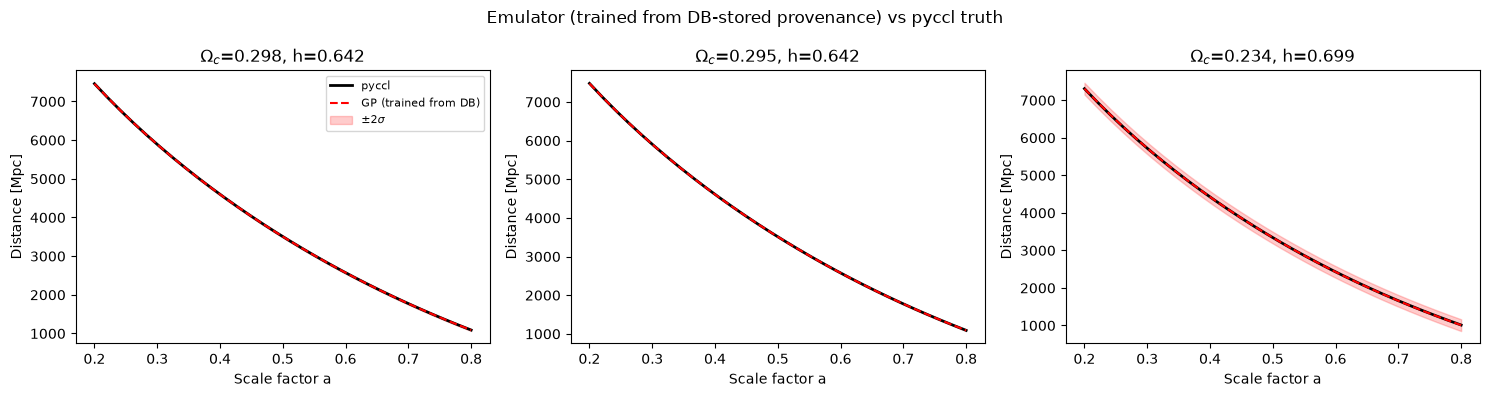

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, params in enumerate(test_samples[:3]):
    truth = comoving_angular_distance(params, a_grid)
    X_pred = params_to_feature_matrix(params, a_grid, PARAM_NAMES)
    pred, std = emu.predict_with_std(X_pred)

    ax = axes[i]
    ax.plot(a_grid, truth, "k-", lw=2, label="pyccl")
    ax.plot(a_grid, pred, "r--", lw=1.5, label="GP (trained from DB)")
    ax.fill_between(a_grid, pred - 2 * std, pred + 2 * std, alpha=0.2, color="red", label=r"$\pm 2\sigma$")
    ax.set_xlabel("Scale factor a")
    ax.set_ylabel("Distance [Mpc]")
    ax.set_title(f"$\\Omega_c$={params['Omega_c']:.3f}, h={params['h']:.3f}")
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Emulator (trained from DB-stored provenance) vs pyccl truth", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the complete pipeline connecting all three packages:

```
CosmologyParams (macon CRUD)
  -> comoving_angular_distance (pyccl, @track provenance)
    -> execution/node/edge records (tisserande DB)
      -> query_computation_results (reconstruct training data)
        -> GPEmulator.fit (train surrogate)
          -> emulator.predict (replace pyccl)
```

Key points:
- **No data was re-computed** to train the emulator — it was all queried from the DB
- **Provenance is automatic** — the `@track` decorator records everything
- **The emulator trains on the exact same data** that was computed and stored
- **CosmologyParams records** provide a searchable catalog of parameter sets alongside the provenance graph

In [13]:
# Cleanup
import os
from tisserande.tracking.decorator import reset
reset()
asyncio.run(close_db())
if os.path.exists("pipeline_demo.db"):
    os.remove("pipeline_demo.db")
    print("Cleaned up pipeline_demo.db")

Cleaned up pipeline_demo.db
